In [1]:
library(mashr)
library(dplyr)
library(tidyr)
library(vroom)

Loading required package: ashr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
cts <- c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Myeloid','NK','T')

In [3]:
in.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/'
out.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/mashr/'
dir.create(out.dir)

Warning message in dir.create(out.dir):
“'/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/mashr' already exists”


# Subset summary stats:  
Ran on TSCC

# Get lead signals

In [4]:
sig.signals <- data.frame()
for (cell in cts) {
    ct.res <- read.table(paste0(in.dir,cell,'.cis_qtl.txt.gz'), header=T)
    ct.res$cell <- cell
    ct.res <- filter(ct.res, qval < 0.05)
    sig.signals <- rbind(sig.signals, ct.res)
    gc()
}

dim(sig.signals)
head(sig.signals)

[1] 10591    20

,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,ma_samples,ma_count,af,pval_nominal,slope,slope_se,pval_perm,pval_beta,qval,pval_nominal_threshold,cell
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,chr12-9283821-9284121,4337,1.03606,272.0130,44.9198,3.43131e-13,rs5796344,-4648,-4947,63,84,0.488372,2.57991e-15,-1.000530,0.0908425,9.999e-05,3.99529e-11,7.98081e-07,9.23314e-08,B
2,chr12-131682212-131682512,4637,1.04718,312.3210,43.8661,9.79265e-09,rs55661795,10972,10673,63,84,0.488372,2.81074e-10,0.778518,0.1004540,9.999e-05,1.64575e-06,6.57497e-03,9.04172e-08,B
3,chr17-20677563-20677863,1679,1.01970,72.2359,43.9483,9.45415e-08,rs16941336,-5180,-5479,47,57,0.331395,4.45940e-09,-0.811524,0.1158820,9.999e-05,5.35783e-06,1.78376e-02,2.91252e-07,B
4,chr8-8227864-8228164,3087,1.00977,115.5090,42.2734,6.46651e-10,rs2001840,33861,33562,53,73,0.575581,4.33253e-12,-0.973878,0.1095270,9.999e-05,6.33631e-08,4.72093e-04,1.63162e-07,B
5,chr8-8228311-8228611,3088,1.03720,107.3010,41.0597,1.21096e-09,rs13259216,587779,587480,54,71,0.587209,4.67622e-12,-0.982174,0.1107230,9.999e-05,7.09005e-08,4.72093e-04,2.36873e-07,B
6,chr9-128192843-128193143,2205,1.05066,129.0620,43.7866,8.03715e-09,rs7853212,115,-184,51,59,0.343023,2.13332e-10,1.114800,0.1424720,9.999e-05,5.04891e-07,2.52137e-03,2.26823e-07,B


In [5]:
sig.signals$feature_variant <- paste0(sig.signals$phenotype_id, ":", sig.signals$variant_id)

In [6]:
length(unique(sig.signals$feature_variant))

[1] 10198

In [7]:
sig.signals <- arrange(sig.signals, qval) %>%
    filter(!duplicated(feature_variant))
sig.signals

phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,ma_samples,⋯,af,pval_nominal,slope,slope_se,pval_perm,pval_beta,qval,pval_nominal_threshold,cell,feature_variant
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
chr12-9283821-9284121,4337,1.08214,237.040,43.3088,2.76466e-23,rs5796344,-4648,-4947,63,⋯,0.488372,3.55864e-28,-1.22839,0.0562211,9.999e-05,1.38909e-22,2.05491e-17,5.25150e-06,Myeloid,chr12-9283821-9284121:rs5796344
chr10-23505781-23506081,3651,1.04980,156.177,43.3069,1.18440e-23,rs983990,11671,11372,52,⋯,0.377907,1.25831e-28,-1.21128,0.0542479,9.999e-05,1.67976e-22,8.36854e-17,5.69625e-06,Hepatocytes,chr10-23505781-23506081:rs983990
chr20-1588581-1588881,4626,1.00997,364.622,43.5957,9.94890e-24,rs2253814,-23053,-23352,29,⋯,0.779070,1.54165e-28,-1.06249,0.0477859,9.999e-05,2.25932e-21,1.67113e-16,2.04942e-06,Myeloid,chr20-1588581-1588881:rs2253814
chr12-131851267-131851567,4501,1.03809,314.623,44.1470,1.20253e-22,rs7487262,1087,788,62,⋯,0.540698,6.69115e-27,-1.26819,0.0617410,9.999e-05,6.77648e-21,8.44011e-16,2.59905e-06,Hepatocytes,chr12-131851267-131851567:rs7487262
chr20-7258122-7258422,4432,1.03248,271.635,45.8164,8.56720e-23,rs17394617,-9080,-9379,30,⋯,0.191860,3.83338e-26,-1.23745,0.0625238,9.999e-05,5.28507e-21,8.44011e-16,2.88934e-06,Hepatocytes,chr20-7258122-7258422:rs17394617
chr8-20570663-20570963,5325,1.04664,391.400,44.1256,1.16007e-22,rs1580343,10306,10007,52,⋯,0.401163,6.22806e-27,-1.23780,0.0601700,9.999e-05,5.57410e-21,8.44011e-16,2.22237e-06,Hepatocytes,chr8-20570663-20570963:rs1580343
chr12-9283821-9284121,4337,1.05087,250.723,44.3227,5.01237e-22,rs2113899,-2935,-3234,62,⋯,0.523256,4.65008e-26,-1.28011,0.0649469,9.999e-05,1.34333e-20,1.11542e-15,3.57552e-06,Hepatocytes,chr12-9283821-9284121:rs2113899
chr22-23971026-23971326,3792,1.03817,244.941,44.9500,2.54201e-22,rs5751764,-63756,-64055,65,⋯,0.511628,4.61148e-26,-1.21494,0.0616298,9.999e-05,1.13246e-20,1.11542e-15,3.34037e-06,Hepatocytes,chr22-23971026-23971326:rs5751764
chr7-76613849-76614123,3630,1.02801,221.237,44.8598,4.56810e-22,rs711306,-3687,-3960,55,⋯,0.540698,8.22080e-26,-1.18488,0.0608536,9.999e-05,2.93300e-20,2.08746e-15,3.43227e-06,Hepatocytes,chr7-76613849-76614123:rs711306


In [8]:
write.table(sig.signals$feature_variant, paste0(in.dir, 'sig.feature.variant.pairs.txt'),
           quote=F, row.names=F, col.names=F, sep='\t')

# Get all signals

# Read in data

In [12]:
saved_col_names <- colnames(read.table(paste0(in.dir,'Cholangiocyte.cis_qtl_pairs.chr9.parquet.thresh.tsv'), sep='\t', nrows = 1,header=T))
saved_col_names

[1] "phenotype_id"           "variant_id"             "start_distance"        
 [4] "end_distance"           "af"                     "ma_samples"            
 [7] "ma_count"               "pval_nominal"           "slope"                 
[10] "slope_se"               "pval_nominal_threshold" "sig.qtl"

In [30]:
sig.signal.sum.stats <- list()

for (cell in cts) {
    ct.res <- vroom(paste0(in.dir,cell,'.cis_qtl_pairs.sig.mash.tsv'), col_names = saved_col_names)
    gc()
    ct.res$feature_variant <- paste0(ct.res$phenotype_id, ":", ct.res$variant_id)
    
    ct.res <- filter(ct.res, variant_id != '.')
    
    sig.signal.sum.stats[[cell]] <- ct.res
    gc()
}

summary(sig.signal.sum.stats)
dim(sig.signal.sum.stats[['Hepatocytes']])
head(sig.signal.sum.stats[['Hepatocytes']])

Rows: 593 Columns: 12
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (9): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...
lgl (1): sig.qtl

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1466 Columns: 12
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (9): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...
lgl (1): sig.qtl

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 4

              Length Class       Mode
B             13     spec_tbl_df list
Cholangiocyte 13     spec_tbl_df list
Endothelial   13     spec_tbl_df list
Hepatocytes   13     spec_tbl_df list
HSC           13     spec_tbl_df list
Myeloid       13     spec_tbl_df list
NK            13     spec_tbl_df list
T             13     spec_tbl_df list

[1] 9777   13

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,pval_nominal_threshold,sig.qtl,feature_variant
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
chr1-976057-976357,rs7417106,157,-142,0.7674419,35,40,4.481157e-14,-1.33184520,0.13082062,1.23005e-05,TRUE,chr1-976057-976357:rs7417106
chr1-1005257-1005557,rs2799056,-633,-932,0.3895349,55,67,8.059259e-08,-0.56517980,0.09085973,1.10004e-05,TRUE,chr1-1005257-1005557:rs2799056
chr1-1420065-1420365,rs3766165,-852,-1151,0.1976744,28,34,3.048896e-09,-0.84486610,0.11890069,5.97068e-06,TRUE,chr1-1420065-1420365:rs3766165
chr1-1543678-1543978,rs1571149,-4892,-5191,0.4941860,63,85,4.467289e-07,-0.89630940,0.15580592,5.23731e-06,TRUE,chr1-1543678-1543978:rs1571149
chr1-1680933-1681233,rs4074198,230,-69,0.4476744,60,77,8.428940e-01,-0.03547485,0.17811579,5.57986e-06,FALSE,chr1-1680933-1681233:rs4074198
chr1-1692642-1692942,rs6695303,-12429,-12728,0.4593023,61,79,3.966782e-08,-0.72804710,0.11353350,4.63782e-06,TRUE,chr1-1692642-1692942:rs6695303


In [31]:
rand.signal.sum.stats <- list()

for (cell in cts) {
    ct.res <- vroom(paste0(in.dir,cell,'.cis_qtl_pairs.rand.tsv'), col_names = saved_col_names)
    gc()
    ct.res$feature_variant <- paste0(ct.res$phenotype_id, ":", ct.res$variant_id)
    
    ct.res <- filter(ct.res, variant_id != '.')
    
    rand.signal.sum.stats[[cell]] <- ct.res
}

summary(rand.signal.sum.stats)
dim(rand.signal.sum.stats[['Hepatocytes']])
head(rand.signal.sum.stats[['Hepatocytes']])

Rows: 6847 Columns: 12
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (9): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...
lgl (1): sig.qtl

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 15379 Columns: 12
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (9): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...
lgl (1): sig.qtl

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows:

              Length Class       Mode
B             13     spec_tbl_df list
Cholangiocyte 13     spec_tbl_df list
Endothelial   13     spec_tbl_df list
Hepatocytes   13     spec_tbl_df list
HSC           13     spec_tbl_df list
Myeloid       13     spec_tbl_df list
NK            13     spec_tbl_df list
T             13     spec_tbl_df list

[1] 192206     13

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,pval_nominal_threshold,sig.qtl,feature_variant
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
chr1-820201-820501,rs111304798,149447,149148,0.05813953,10,10,0.05682572,0.85194810,0.4375391,1.10856e-05,FALSE,chr1-820201-820501:rs111304798
chr1-942401-942701,rs1695856,480544,480245,0.08720930,13,15,0.73281389,-0.10351282,0.3016205,1.15761e-05,FALSE,chr1-942401-942701:rs1695856
chr1-947961-948261,rs2298214,51880,51581,0.50581396,64,85,0.72372831,0.07156827,0.2013950,1.11680e-05,FALSE,chr1-947961-948261:rs2298214
chr1-1005257-1005557,rs1695823,425650,425351,0.47093022,58,81,0.74399378,0.03912182,0.1191723,1.10004e-05,FALSE,chr1-1005257-1005557:rs1695823
chr1-1025179-1025479,rs78308511,-88473,-88772,0.06395349,10,11,0.51686344,0.20054863,0.3073281,1.10757e-05,FALSE,chr1-1025179-1025479:rs78308511
chr1-1038769-1039069,rs9439458,477230,476931,0.36046510,49,62,0.02092256,-0.49150676,0.2064819,8.43150e-06,FALSE,chr1-1038769-1039069:rs9439458


# Create random mash object and estimate correlation

In [33]:
bhat_rand <- bind_rows(rand.signal.sum.stats, .id = "cell") %>%
    select(cell, feature_variant, slope) %>%
    pivot_wider(names_from = 'cell',values_from = 'slope') %>%
    tibble::column_to_rownames(var='feature_variant') %>%
    as.matrix()

dim(bhat_rand)
head(bhat_rand)

[1] 199998      8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
chr1-1399370-1399670:rs79339398,0.20018923,0.17700500,-0.32981250,-0.02469044,0.05888622,0.13692234,0.07159284,-0.02559729
chr1-1574771-1575071:rs139295104,-0.25613514,0.33438262,0.28051153,0.24536692,0.04519567,0.13392095,0.49609536,0.16009405
chr1-1629210-1629510:rs57414802,0.22111894,NA,-0.59372467,-0.40196985,-0.30013078,0.52181894,-0.66193140,-0.03335470
chr1-1692642-1692942:rs2678945,-0.01588638,0.08383655,-0.10491517,-0.20262626,-0.16006479,-0.24912956,-0.24815051,0.12904700
chr1-1778323-1778623:rs34166899,-0.20423144,0.12444295,0.26709658,0.11252984,0.21181111,-0.02053679,-0.13987440,0.15690838
chr1-1778323-1778623:rs2843166,-0.18590526,0.10866260,-0.08065499,-0.24112093,-0.31338242,-0.10038849,-0.06467741,0.03783015


In [34]:
shat_rand <- bind_rows(rand.signal.sum.stats, .id = "cell") %>%
    select(cell, feature_variant, slope_se) %>%
    pivot_wider(names_from = 'cell',values_from = 'slope_se') %>%
    tibble::column_to_rownames(var='feature_variant') %>%
    as.matrix()

dim(shat_rand)
head(shat_rand)

[1] 199998      8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
chr1-1399370-1399670:rs79339398,0.2112348,0.1945022,0.1238818,0.13653535,0.1954153,0.1590476,0.2290998,0.2146619
chr1-1574771-1575071:rs139295104,0.2848021,0.2138541,0.1933820,0.18509560,0.2000833,0.1920073,0.2561298,0.2413078
chr1-1629210-1629510:rs57414802,0.4328838,NA,0.5544775,0.49959767,0.3959135,0.4129298,0.4440640,0.4496899
chr1-1692642-1692942:rs2678945,0.1376313,0.1298480,0.1351003,0.15415977,0.1409180,0.1327540,0.1891053,0.1551449
chr1-1778323-1778623:rs34166899,0.1431808,0.1248367,0.1457351,0.09667540,0.1663340,0.1420113,0.1255053,0.1272083
chr1-1778323-1778623:rs2843166,0.1341482,0.1193943,0.1336863,0.09454331,0.1453891,0.1412292,0.1183758,0.1305995


In [35]:
sum(rownames(bhat_rand)==rownames(shat_rand)) == nrow(bhat_rand)
sum(colnames(bhat_rand)==colnames(shat_rand)) == ncol(bhat_rand)

[1] TRUE

[1] TRUE

In [36]:
random   = mash_set_data(bhat_rand, shat_rand)
summary(random)

           Length  Class  Mode   
Bhat       1599984 -none- numeric
Shat       1599984 -none- numeric
Shat_alpha 1599984 -none- numeric
V               64 -none- numeric
commonV          1 -none- logical
alpha            1 -none- numeric

In [37]:
Vhat = estimate_null_correlation_simple(random)
Vhat

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
B,1.0000000000,0.0007841672,0.008785207,0.001428541,0.015500672,0.001601022,0.013241511,0.005627953
Cholangiocyte,0.0007841672,1.0000000000,0.007495922,0.010060025,0.012854430,0.002422832,-0.003866106,0.012591485
Endothelial,0.0087852067,0.0074959216,1.000000000,0.007957051,0.018160943,0.010013008,0.007308966,0.006607968
Hepatocytes,0.0014285409,0.0100600251,0.007957051,1.000000000,0.012690610,0.009279994,0.003069821,0.004198547
HSC,0.0155006721,0.0128544301,0.018160943,0.012690610,1.000000000,0.006810333,0.006122516,-0.003593120
Myeloid,0.0016010217,0.0024228321,0.010013008,0.009279994,0.006810333,1.000000000,0.004186372,0.009115495
NK,0.0132415108,-0.0038661057,0.007308966,0.003069821,0.006122516,0.004186372,1.000000000,0.019839608
T,0.0056279532,0.0125914849,0.006607968,0.004198547,-0.003593120,0.009115495,0.019839608,1.000000000


# Recreate random and make strong with correlation matrix from the null (random)

In [40]:
bhat_strong <- bind_rows(sig.signal.sum.stats, .id = "cell") %>%
    select(cell, feature_variant, slope) %>%
    pivot_wider(names_from = 'cell',values_from = 'slope') %>%
    tibble::column_to_rownames(var='feature_variant') %>%
    as.matrix()

dim(bhat_strong)
head(bhat_strong)

[1] 10198     8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
chr1-1692642-1692942:rs6695303,-0.3347229,-0.3695927,-0.5336140,-0.7280471,-0.5051444,-0.5399256,-0.5636672,-0.5463107
chr1-1692642-1692942:rs1062090,-0.4269728,-0.5398354,-0.8508464,-0.7538893,-0.7413297,-0.7137609,-0.6737882,-0.5635200
chr1-1746281-1746581:rs6695303,0.1249455,0.6709556,0.6282905,0.8030273,0.9393445,0.8729315,0.7504100,0.6462340
chr1-1890996-1891296:rs6603802,0.2051542,0.2643214,0.5286415,0.5348966,0.3526842,0.2144248,0.1832596,0.3222353
chr1-1891323-1891623:rs61422524,0.4470376,0.6242691,0.9050660,1.0440012,0.7626023,0.9050516,0.3692331,0.7269340
chr1-1891323-1891623:rs915292,0.4906995,0.6529273,0.9852247,1.0889138,0.8932023,1.0343543,0.4256233,0.8002595


In [41]:
shat_strong <- bind_rows(sig.signal.sum.stats, .id = "cell") %>%
    select(cell, feature_variant, slope_se) %>%
    pivot_wider(names_from = 'cell',values_from = 'slope_se') %>%
    tibble::column_to_rownames(var='feature_variant') %>%
    as.matrix()

dim(shat_strong)
head(shat_strong)

[1] 10198     8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
chr1-1692642-1692942:rs6695303,0.1425920,0.1237997,0.11802211,0.11353350,0.1260592,0.11965784,0.1656746,0.13787982
chr1-1692642-1692942:rs1062090,0.1465437,0.1290294,0.12121578,0.13056874,0.1296964,0.12669207,0.1883625,0.14971629
chr1-1746281-1746581:rs6695303,0.1951101,0.1295732,0.12728795,0.12161948,0.1379933,0.13702560,0.1512577,0.14399360
chr1-1890996-1891296:rs6603802,0.1443294,0.1231396,0.08501606,0.06954122,0.1062264,0.10846633,0.1448315,0.12468047
chr1-1891323-1891623:rs61422524,0.1250981,0.0999233,0.08789699,0.07723495,0.1057461,0.09515144,0.1165111,0.08670700
chr1-1891323-1891623:rs915292,0.1268493,0.1088845,0.08258975,0.07342984,0.1015765,0.07953087,0.1194042,0.07987722


In [42]:
sum(rownames(bhat_strong)==rownames(shat_strong)) == nrow(bhat_strong)
sum(colnames(bhat_strong)==colnames(shat_strong)) == ncol(bhat_strong)

[1] TRUE

[1] TRUE

In [43]:
strong   = mash_set_data(bhat_strong, shat_strong, V = Vhat)
summary(strong)

           Length Class  Mode   
Bhat       81584  -none- numeric
Shat       81584  -none- numeric
Shat_alpha 81584  -none- numeric
V             64  -none- numeric
commonV        1  -none- logical
alpha          1  -none- numeric

In [44]:
random   = mash_set_data(bhat_rand, shat_rand, V=Vhat)
summary(random)

           Length  Class  Mode   
Bhat       1599984 -none- numeric
Shat       1599984 -none- numeric
Shat_alpha 1599984 -none- numeric
V               64 -none- numeric
commonV          1 -none- logical
alpha            1 -none- numeric

In [45]:
saveRDS(random, paste0(out.dir, '241125_WE_200k_random_mashr.RDS'))
saveRDS(strong, paste0(out.dir, '241125_WE_lead_mashr.RDS'))

# Get data driven covariance on the strong

In [46]:
U.pca = cov_pca(strong,5)
U.ed = cov_ed(strong, U.pca)

In [47]:
saveRDS(U.pca, paste0(out.dir, '241125_WE_U.pca.RDS'))
saveRDS(U.ed, paste0(out.dir, '241125_WE_U.ed.RDS'))

# Fit mash to the null set

In [48]:
U.c = cov_canonical(random)
m = mash(random, Ulist = c(U.ed,U.c), outputlevel = 1)

 - Computing 199998 x 400 likelihood matrix.
 - Likelihood calculations took 152.68 seconds.
 - Fitting model with 400 mixture components.
 - Model fitting took 874.52 seconds.


In [49]:
saveRDS(U.c, paste0(out.dir, '241125_WE_U.c.RDS'))
saveRDS(m, paste0(out.dir, '241125_WE_fit_model_m.RDS'))

# Estimate posteriors for set  
Run this again on any additional summary stats we want to estimate, could eventually loop through all

In [50]:
m2 = mash(strong, g=get_fitted_g(m), fixg=TRUE)

 - Computing 10198 x 400 likelihood matrix.
 - Likelihood calculations took 7.13 seconds.
 - Computing posterior matrices.
 - Computation allocated took 0.99 seconds.


In [51]:
saveRDS(m2, paste0(out.dir, '241125_WE_lead_estimates_m2.RDS'))

In [52]:
write.table(get_lfsr(m2), paste0(out.dir, '241125_WE_lead_lfsr.tsv'), 
            sep='\t', quote=F, col.names=T, row.names=T)
write.table(get_pm(m2), paste0(out.dir, '241125_WE_lead_post_mean.tsv'), 
            sep='\t', quote=F, col.names=T, row.names=T)
write.table(get_psd(m2), paste0(out.dir, '241125_WE_lead_post_sd.tsv'), 
            sep='\t', quote=F, col.names=T, row.names=T)

In [53]:
head(get_lfsr(m2))

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
chr1-1692642-1692942:rs6695303,4.998708e-06,2.769574e-09,7.885468e-08,8.744561e-12,5.206649e-07,1.001646e-07,2.852537e-07,1.302514e-08
chr1-1692642-1692942:rs1062090,8.072153e-08,1.120104e-12,5.662137e-15,2.563126e-10,1.121625e-11,4.843381e-11,5.143097e-09,1.747171e-10
chr1-1746281-1746581:rs6695303,1.490714e-07,7.068595e-16,4.572129e-10,1.015848e-12,6.875915e-14,4.288554e-13,5.984611e-12,5.839702e-13
chr1-1890996-1891296:rs6603802,1.592476e-03,4.187899e-05,6.813244e-11,3.998245e-15,2.460050e-05,2.799131e-03,8.876283e-04,1.014163e-04
chr1-1891323-1891623:rs61422524,5.135247e-11,3.795786e-23,6.808187e-28,5.738074e-43,1.026215e-16,3.699745e-24,1.036820e-12,8.687290e-24
chr1-1891323-1891623:rs915292,5.125210e-13,5.695672e-26,9.679670e-37,2.257430e-51,5.453405e-23,5.212239e-42,3.151159e-15,4.616332e-31


In [54]:
summary(m)

                  Length  Class  Mode   
result                  0 -none- NULL   
loglik                  1 -none- numeric
vloglik            199998 -none- numeric
null_loglik        199998 -none- numeric
alt_loglik         199998 -none- numeric
fitted_g                4 -none- list   
posterior_weights 4199958 -none- numeric
alpha                   1 -none- numeric

In [55]:
summary(m2)

                  Length Class  Mode   
result                 4 -none- list   
loglik                 1 -none- numeric
vloglik            10198 -none- numeric
null_loglik        10198 -none- numeric
alt_loglik         10198 -none- numeric
fitted_g               4 -none- list   
posterior_weights 214158 -none- numeric
alpha                  1 -none- numeric

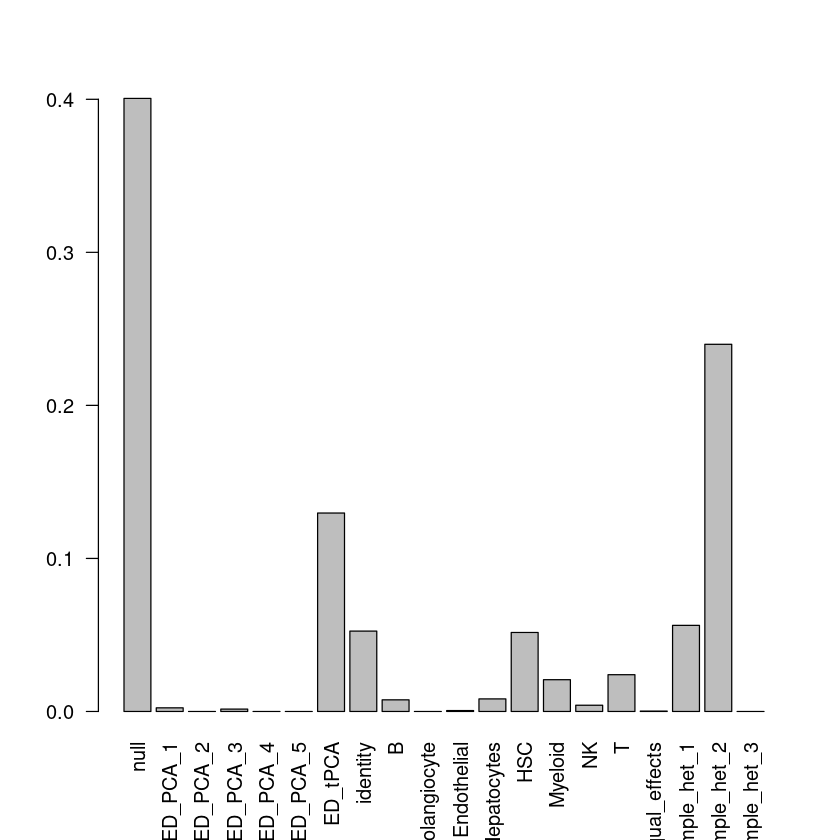

In [56]:
barplot(get_estimated_pi(m2),las = 2)

In [57]:
print(get_pairwise_sharing(m2, factor=0))

                      B Cholangiocyte Endothelial Hepatocytes       HSC
B             1.0000000     0.9997836   0.9899160   0.9800480 0.9948534
Cholangiocyte 0.9997836     1.0000000   0.9883544   0.9789434 0.9948290
Endothelial   0.9899160     0.9883544   1.0000000   0.9175549 0.9917499
Hepatocytes   0.9800480     0.9789434   0.9175549   1.0000000 0.9443978
HSC           0.9948534     0.9948290   0.9917499   0.9443978 1.0000000
Myeloid       0.9918147     0.9883471   0.9712372   0.9056731 0.9846189
NK            0.9997566     0.9993514   0.9896288   0.9789077 0.9939197
T             0.9997661     0.9993544   0.9891459   0.9775701 0.9936575
                Myeloid        NK         T
B             0.9918147 0.9997566 0.9997661
Cholangiocyte 0.9883471 0.9993514 0.9993544
Endothelial   0.9712372 0.9896288 0.9891459
Hepatocytes   0.9056731 0.9789077 0.9775701
HSC           0.9846189 0.9939197 0.9936575
Myeloid       1.0000000 0.9916505 0.9910782
NK            0.9916505 1.0000000 1.0000000


In [58]:
data.frame(matrix(as.numeric(get_lfsr(m2) < .01), ncol=8))

X1,X2,X3,X4,X5,X6,X7,X8
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1
0,0,0,1,0,0,0,0
1,1,1,1,0,1,1,1
1,1,0,1,0,1,1,1


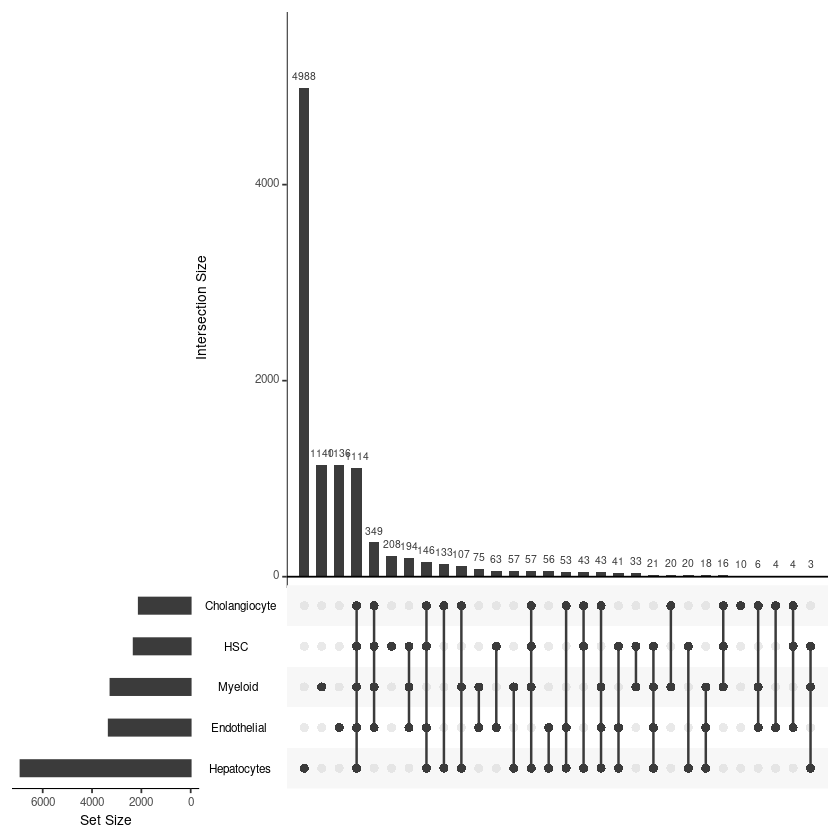

In [59]:
library(UpSetR)

upset_data <- data.frame(matrix(as.numeric(get_lfsr(m2) < .01), ncol=8))
colnames(upset_data) <- colnames(get_lfsr(m2))

upset(upset_data, order.by = "freq")

In [4]:
out.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/mashr/'
lfsr <- read.table(paste0(out.dir, '241125_WE_lead_lfsr.tsv'), sep='\t', header=T)
dim(lfsr)
head(lfsr)

library(UpSetR)

pdf('/nfs/lab/welison/Liver/Plots/241213_WE_ATAC_QTL_Specificifty_Upset.pdf', height=6, width=10)

upset_data <- data.frame(matrix(as.numeric(lfsr < .01), ncol=8))
colnames(upset_data) <- colnames(lfsr)

upset(upset_data, order.by = "freq", text.scale = 2, nintersects=15)

dev.off()

[1] 10198     8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1-1692642-1692942:rs6695303,4.998708e-06,2.769574e-09,7.885468e-08,8.744561e-12,5.206649e-07,1.001646e-07,2.852537e-07,1.302514e-08
chr1-1692642-1692942:rs1062090,8.072153e-08,1.120104e-12,5.662137e-15,2.563126e-10,1.121625e-11,4.843381e-11,5.143097e-09,1.747171e-10
chr1-1746281-1746581:rs6695303,1.490714e-07,7.068595e-16,4.572129e-10,1.015848e-12,6.875915e-14,4.288554e-13,5.984611e-12,5.839702e-13
chr1-1890996-1891296:rs6603802,1.592476e-03,4.187899e-05,6.813244e-11,3.998245e-15,2.460050e-05,2.799131e-03,8.876283e-04,1.014163e-04
chr1-1891323-1891623:rs61422524,5.135247e-11,3.795786e-23,6.808187e-28,5.738074e-43,1.026215e-16,3.699745e-24,1.036820e-12,8.687290e-24
chr1-1891323-1891623:rs915292,5.125210e-13,5.695672e-26,9.679670e-37,2.257430e-51,5.453405e-23,5.212239e-42,3.151159e-15,4.616332e-31


png 
  2

In [3]:
?upset